In [3]:
from tritonix.utils import hilbert

In [4]:
# Example: list the Hilbert-swizzled coordinates for a 4x8 grid
hilbert.hilbert_swizzled_coords(4, 8)

[(0, 0),
 (1, 0),
 (1, 1),
 (0, 1),
 (0, 2),
 (0, 3),
 (1, 3),
 (1, 2),
 (2, 2),
 (2, 3),
 (3, 3),
 (3, 2),
 (3, 1),
 (2, 1),
 (2, 0),
 (3, 0),
 (3, 7),
 (2, 7),
 (2, 6),
 (3, 6),
 (3, 5),
 (3, 4),
 (2, 4),
 (2, 5),
 (1, 5),
 (1, 4),
 (0, 4),
 (0, 5),
 (0, 6),
 (1, 6),
 (1, 7),
 (0, 7)]

In [10]:
# Visualization helper for Hilbert swizzle paths over an m x n block grid
from typing import Optional
import matplotlib.pyplot as plt


def plot_hilbert_swizzle(
    coords,
    m: int,
    n: int,
    *,
    annotate_every: Optional[int] = None,
    show_start_end: bool = True,
    figsize=(6, 6),
    line_color: str = "#1f77b4",
):
    """Plot the Hilbert swizzle path across an m x n grid of MMA blocks.

    Args:
        m: Number of block rows (e.g., MMA tiles in M-dimension).
        n: Number of block cols (e.g., MMA tiles in N-dimension).
        annotate_every: If set (e.g., 8), label every k-th step along the path.
        show_start_end: Highlight start (green) and end (red) nodes.
        figsize: Matplotlib figure size.
        line_color: Color for the path line and markers.
    """

    fig, ax = plt.subplots(figsize=figsize)

    # Draw grid lines
    for i in range(m + 1):
        ax.plot([0, n], [i, i], color="#dddddd", linewidth=0.8, zorder=0)
    for j in range(n + 1):
        ax.plot([j, j], [0, m], color="#dddddd", linewidth=0.8, zorder=0)

    # Centers of blocks for the path
    xs = [j + 0.5 for (i, j) in coords]
    ys = [i + 0.5 for (i, j) in coords]

    # Plot the swizzle path
    ax.plot(xs, ys, "-o", color=line_color, markersize=3, linewidth=1.5, zorder=2)

    if show_start_end and len(xs) > 0:
        ax.scatter(xs[0], ys[0], color="green", s=50, zorder=3, label="start")
        ax.scatter(xs[-1], ys[-1], color="red", s=50, zorder=3, label="end")
        ax.legend(loc="upper right", frameon=False)

    if annotate_every is not None and annotate_every > 0:
        for k, (x, y) in enumerate(zip(xs, ys)):
            if k % annotate_every == 0 or k in (0, len(xs) - 1):
                ax.text(x, y, str(k), fontsize=8, color="black", ha="center", va="center")

    # Aesthetics: show block indices at centers, origin at top-left like matrices
    ax.set_xlim(0, n)
    ax.set_ylim(0, m)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([j + 0.5 for j in range(n)])
    ax.set_xticklabels([str(j) for j in range(n)], fontsize=8)
    ax.set_yticks([i + 0.5 for i in range(m)])
    ax.set_yticklabels([str(i) for i in range(m)], fontsize=8)
    ax.invert_yaxis()

    ax.set_title(f"Hilbert swizzle path over {m}x{n} blocks")
    ax.set_xlabel("Block column (N tiles)")
    ax.set_ylabel("Block row (M tiles)")

    plt.tight_layout()
    plt.show()

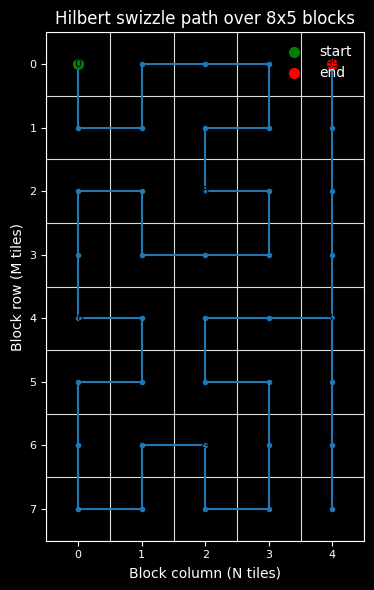

In [11]:
# Plot a sample swizzle path
plot_hilbert_swizzle(
    hilbert.hilbert_swizzled_coords(8, 5),
    8,
    5,
    annotate_every=8,
)

In [13]:
def swizzle2d_rows(i, j, size_i, size_j, size_g):
    ij = i * size_j + j
    num_groups_per_stripe = size_g * size_j
    group_id = ij // num_groups_per_stripe
    group_start = group_id * size_g
    group_size = min(size_i - group_start, size_g)

    pid_m = group_start + (ij % num_groups_per_stripe) % group_size
    pid_n = (ij % num_groups_per_stripe) // group_size
    group_m = pid_m // size_g
    is_odd_group = group_m % 2 == 1
    start = is_odd_group * (size_j - 1)
    if group_m % 2 == 1:
        start = size_j - 1
        pid_n = size_j - 1 - pid_n
    if (start - pid_n) % 2 == 1:
        pid_m = (
            pid_m
            - 2 * ((ij % num_groups_per_stripe) % group_size)
            - 1
            + group_size
        )
    return pid_m, pid_n

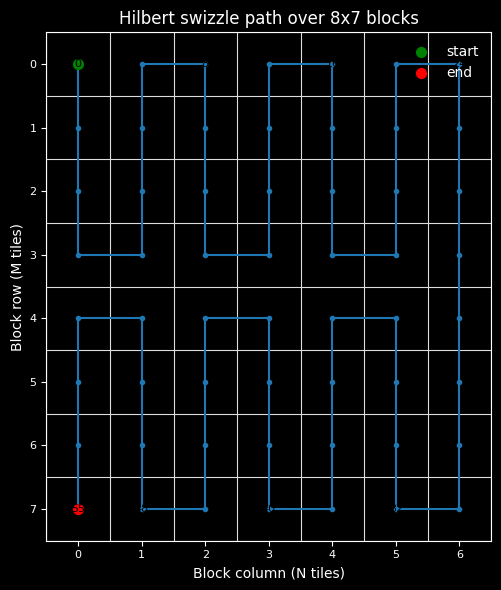

In [19]:
import numpy as np
m = 8
n = 7
coords = []
for i in range(m):
    for j in range(n):
        coords.append(swizzle2d_rows(i,j, m,n,4))
coords = np.array(coords)


plot_hilbert_swizzle(
    coords,
    m,
    n,
    annotate_every=8,
)

In [10]:
def swizzle2d(pid_m, pid_n, num_pid_m, num_pid_n, group_size):
    num_pid_in_group = group_size * num_pid_n
    pid = (pid_m*num_pid_n + pid_n)
    group_id = pid // num_pid_in_group
    first_pid_m = group_id * group_size
    group_size_m = min(num_pid_m - first_pid_m, group_size)
    pid_m = first_pid_m + ((pid % num_pid_in_group) % group_size_m)
    pid_n = (pid % num_pid_in_group) // group_size_m
    return pid_m, pid_n

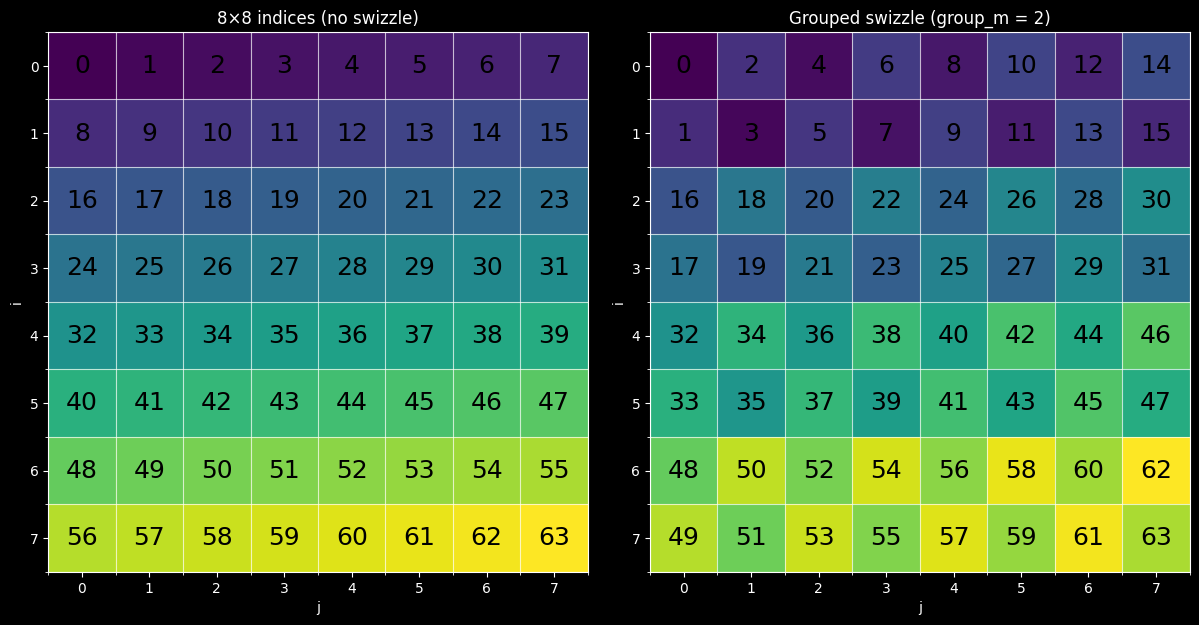

In [13]:
import numpy as np
import matplotlib.pyplot as plt

M = N = 8
group_m = 2  # must be a power of two for this XOR swizzle

def xor_swizzle_row(i: int, j: int, group_m: int) -> int:
    """
    Row swizzle used to reduce bank conflicts in shared memory.
    Within each group of `group_m` consecutive rows, we XOR the
    low bits of the row index with (j % group_m).
    For group_m=2: rows swap within (0,1), (2,3), ... whenever j is odd.
    """
    mask = group_m - 1
    return (i & ~mask) | ((i ^ (j & mask)) & mask)

# Base matrix: linear indices (just to add color variation)
base = np.arange(M * N).reshape(M, N)

# Swizzled matrix: place the same linear indices but at swizzled row positions
swizzled = np.empty_like(base)
for i in range(M):
    for j in range(N):
        si = xor_swizzle_row(i, j, group_m)
        swizzled[si, j] = base[i, j]

fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

# Helper to draw a nice grid
def draw_grid(ax, M, N):
    ax.set_xticks(np.arange(N))
    ax.set_yticks(np.arange(M))
    ax.set_xticklabels([str(x) for x in range(N)])
    ax.set_yticklabels([str(y) for y in range(M)])
    ax.set_xlim(-0.5, N - 0.5)
    ax.set_ylim(M - 0.5, -0.5)  # row 0 at the top
    ax.set_aspect('equal', 'box')
    ax.set_xlabel('j')
    ax.set_ylabel('i')
    # cell borders
    ax.set_xticks(np.arange(-0.5, N, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, M, 1), minor=True)
    ax.grid(which='minor', linewidth=0.8, linestyle='-', alpha=0.7)

# Left: plain (i, j) labeling
ax0 = axes[0]
im0 = ax0.imshow(base)
draw_grid(ax0, M, N)
ax0.set_title("8×8 indices (no swizzle)")
for i in range(M):
    for j in range(N):
        ax0.text(j, i, f"{i*8+j}", ha='center', va='center', fontsize=18, color='black')

# Right: XOR swizzled with group_m=2, label each cell by its ORIGINAL (i, j)
ax1 = axes[1]
im1 = ax1.imshow(swizzled)
draw_grid(ax1, M, N)
ax1.set_title(f"Grouped swizzle (group_m = {group_m})")
cell = 0
for i in range(M):
    for j in range(N):
        # si = xor_swizzle_row(i, j, group_m)
        si,sj = swizzle2d(i,j,8,8,2)
        ax1.text(sj,si, f"{cell}", ha='center', va='center', fontsize=18, color='black')
        cell+=1

plt.show()